from the scRNA-seq annotation to identify the cell type in stRNA-seq 

# work start

In [1]:
# "/cluster/huanglab/dhong/project/HumanSpine/Work/SelectCells/" # data.lib
library(dplyr)
library(ggplot2)
library(Seurat)
library(patchwork)
library(randomcoloR)
set.seed(1)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching SeuratObject

‘SeuratObject’ was built under R 4.3.1 but the current version is
4.3.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Warning message:
“package ‘patchwork’ was built under R version 4.3.3”


# spatial data

In [5]:
#spatial bin30
obj <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/Smooth/RDS/SeuratObj_gw16.rds")
obj <- subset(obj, subset = nCount_Spatial > 300)
obj

An object of class Seurat 
26991 features across 17032 samples within 1 assay 
Active assay: RNA (26991 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: cod

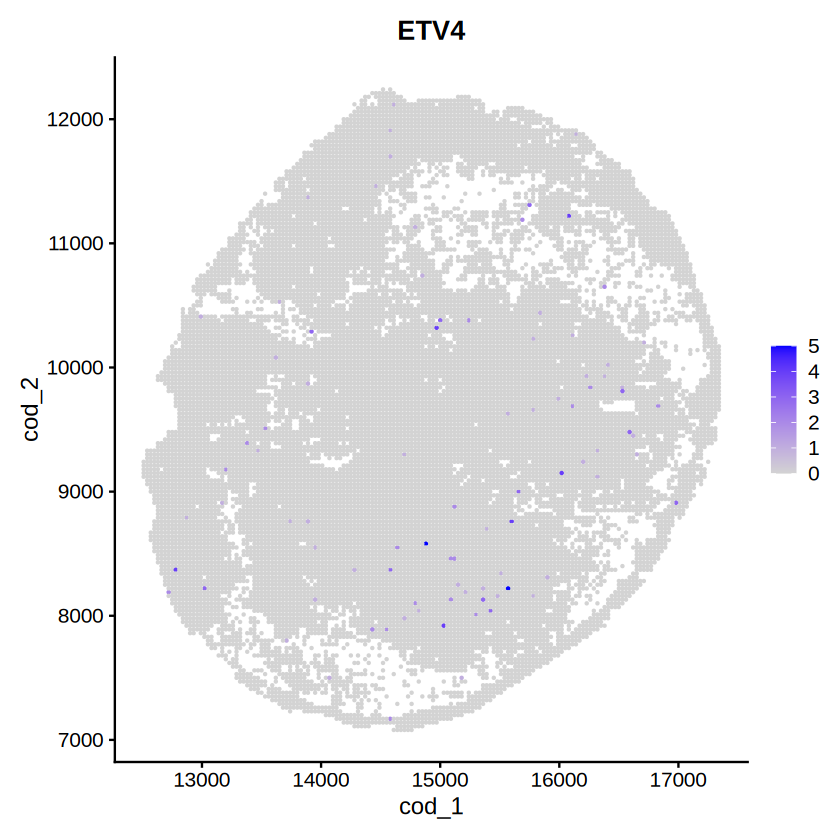

In [6]:
FeaturePlot(obj, features = c("ETV4"), reduction = "cod", pt.size = 0.2)

## clustering

In [7]:
obj = NormalizeData(obj) %>%
    FindVariableFeatures() %>%
    ScaleData() %>%
    RunPCA() %>%
    RunUMAP(dims = 1:15) %>%
    FindNeighbors(dims = 1:15) %>%
    FindClusters(resolution = 0.5)

Centering and scaling data matrix

PC_ 1 
Positive:  STMN2, TUBB2A, TUBA1A, NEFL, GAP43, NEFM, SST, PENK, KCNIP4, PRRT2 
	   SV2A, CADM2, TAC1, NPY, CCK, ERBB4, CLCN4, KCND2, OLFM3, GPC5 
	   NPPC, KHDRBS2, PCDH15, DOC2A, HSDL1, RNF175, PLD5, RAB9B, UGCG, GFOD1 
Negative:  COL3A1, COL1A2, COL1A1, HBG2, VIM, HBG1, HBA2, HBA1, GFAP, IGFBP5 
	   PLP1, MBP, HBB, PTN, CLDN5, SPP1, MAG, MPZ, TF, ACTA2 
	   SPARCL1, ENPP2, CAVIN2, CAV1, ITGA8, MYLK, FAM210B, ERLIN2, GLI3, CASP6 
PC_ 2 
Positive:  MBP, PLP1, GFAP, MAG, TF, ENPP2, SPARCL1, GAL3ST1, CARNS1, RSPH1 
	   C9orf24, CENPF, CAPS, BACE1, FOXJ1, KIF9, AK1, PDGFA, FAM183A, SGCZ 
	   TMEM125, EFNB3, FUBP3, SPP1, AGTRAP, SEMA5B, CAPSL, FEN1, CFTR, STARD4-AS1 
Negative:  HBG1, HBG2, HBA1, HBA2, COL1A2, COL3A1, HBB, COL1A1, IGFBP5, STMN2 
	   GAP43, PTN, TUBB2A, CLDN5, PENK, SST, NPY, NEFL, PRRT2, CCK 
	   KCNIP4, TAC1, NEFM, ITGA8, NPPC, SV2A, CAV1, DOC2A, ACTA2, AP3S1 
PC_ 3 
Positive:  NEFL, NEFM, MBP, PLP1, STMN2, MAG, TF, HBG2, HBG1, TUB

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17032
Number of edges: 491193

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8060
Number of communities: 12
Elapsed time: 1 seconds


In [8]:
obj = RunTSNE(obj, dims = 1:15, check_duplicates = FALSE)
# ElbowPlot(obj,ndims = 50)
obj$individual_clusters = paste0("C",obj$seurat_clusters)
table(obj$individual_clusters)


  C0   C1  C10  C11   C2   C3   C4   C5   C6   C7   C8   C9 
3809 2320  256  221 2057 1780 1755 1390 1266  839  794  545 

In [9]:
length(unique(obj$individual_clusters))

[1] 12

In [10]:
obj$individual_clusters = factor(obj$individual_clusters,levels = paste0("C",0:(length(unique(obj$individual_clusters))-1)))

p1 check stRNA obj quality 

In [11]:
palette <- distinctColorPalette(length(unique(obj$individual_clusters)))
p1 = DimPlot(obj, reduction = "umap", group.by = "individual_clusters", cols = palette, pt.size = 0.2) +
    DimPlot(obj, reduction = "cod", group.by = "individual_clusters", cols = palette, pt.size = 1)

In [12]:
pdf("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/plot/p1_Dimplot_cluster.pdf", height = 6, width = 12)
print(p1)
dev.off()

pdf 
  2

# integration

In [13]:
#snMulti-omics data
snMulti_GW16 <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/rds/0.SeuratObj_GW16_raw.rds")
DefaultAssay(snMulti_GW16) <- "RNA"
snMulti_GW16

Loading required package: Signac

Signac built for for SeuratObject v4 was just loaded with SeuratObject
v5; disabling v5 assays and validation routines, and ensuring assays
work in strict v3/v4 compatibility mode



An object of class Seurat 
181062 features across 20000 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC

In [14]:
# Load the metadata table
mat = read.table("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/Annotation/metadata_snRNA.csv",sep = ",", header = T, row.names = 1)
head(mat)

,Sample,batch,sample2,barcode2,cluster,UMAP_1,UMAP_2,dataset,nUMI,nGene,⋯,Seurat_cell_type,barcode,cell_state,type,cell_name,cell_type,time,cell_type_major,cell_type_snRNA,major_type
,<chr>,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACAGCCAGCAAGAT-1-0,GW7,0,GW6,AAACAGCCAGCAAGAT-1,6,1.980763,5.46784274,rna_GW6,3658,2165,⋯,APC,AAACAGCCAGCAAGAT-1,GW6:APC,rna,APC/pMN,APC,GW6,AST,APC_ventral,APC_AST
AAACAGCCATAAAGCA-1-0,GW7,0,GW6,AAACAGCCATAAAGCA-1,22,2.296306,-8.41525158,rna_GW6,3391,1933,⋯,multipotential_v,AAACAGCCATAAAGCA-1,GW6:multipotential_v,rna,multipotential_v,multipotential_v,GW6,v0/1,InN_ventral_2,InN
AAACAGCCATCGTTCT-1-0,GW7,0,GW6,AAACAGCCATCGTTCT-1,28,4.665377,5.04044024,rna_GW6,6080,2889,⋯,NPC_pro_to_vIPC,AAACAGCCATCGTTCT-1,GW6:NPC_to_APC_OPC_p0/1_progenitor,rna,NPC_proliferative,NPC_pro_to_vIPC,GW6,NPC,NPC,NPC
AAACAGCCATTAGGTT-1-0,GW7,0,GW6,AAACAGCCATTAGGTT-1,35,8.468748,3.75299946,rna_GW6,7095,3057,⋯,EC,AAACAGCCATTAGGTT-1,GW6:EC,rna,EC,EC,GW6,EC,Schwann,Schwann
AAACCAACAAAGCTCC-1-0,GW7,0,GW6,AAACCAACAAAGCTCC-1,38,6.415696,0.04246854,rna_GW6,2830,1653,⋯,Micro,AAACCAACAAAGCTCC-1,GW6:Microglia,rna,Microglia,Micro,GW6,Micro,Microglia,Microglia
AAACCAACAACTAGAA-1-0,GW7,0,GW6,AAACCAACAACTAGAA-1,10,-2.970929,-11.04775509,rna_GW6,4340,2196,⋯,di1_di2?,AAACCAACAACTAGAA-1,GW6:di1,rna,di1,di1_di2?,GW6,di1/2,ExN_immature_2,ExN


In [15]:
mat = mat[mat$sample2 == "GW16", c('UMAP_1', 'UMAP_2', 'barcode2', 'cell_type_snRNA', 'major_type')]
rownames(mat) <- mat$barcode2

In [16]:
# Keep the cells that satisfy the selection criteria
rna <- subset(snMulti_GW16, cells = mat$barcode2)
# Merge `mat` into `meta.data`
rna@meta.data <- cbind(rna@meta.data, mat)
umap_coords <- rna@meta.data[, c("UMAP_1", "UMAP_2")]
umap_coords <- as.matrix(umap_coords)
colnames(umap_coords) <- c("UMAP_1", "UMAP_2")
rna@reductions$umap <- CreateDimReducObject(
    embeddings = umap_coords,
    key = "UMAP_",  # Standard Seurat UMAP key name
    assay = "RNA"   # Specify the associated assay
  )
rna

An object of class Seurat 
181062 features across 15090 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 1 dimensional reduction calculated: umap

In [17]:
rna@meta.data$celltype = rna@meta.data$cell_type_snRNA
table(rna@meta.data$celltype)


      APC_cycling        APC_dorsal       APC_ventral               AST 
              684              1215              1226                53 
              COP                EC    ExN_immature_1    ExN_immature_2 
              876               219               474               563 
   ExN_immature_3      ExN_mature_1      ExN_mature_2      ExN_mature_3 
               63               642               185               166 
        ExN_naive       ExN_ventral                FP    InN_immature_1 
              135               411               169               578 
   InN_immature_2      InN_mature_1      InN_mature_2         InN_naive 
              200               551               183                34 
    InN_ventral_1     InN_ventral_2     InN_ventral_3               IPC 
              128               261               180               570 
             MFOL         Microglia               MN1               MN2 
              549               515               

In [18]:
# Count cells in each cell type
cell_counts <- table(rna@meta.data$celltype)
# Define the manually excluded cell types
manual_exclude <- c("Schwann")
# Low-abundance cell types
less_than <- names(cell_counts[cell_counts < 10])
# Combine all cell types to exclude
all_exclude <- unique(c(manual_exclude, less_than))
# Determine the cell types to retain
keep_types <- setdiff(names(cell_counts), all_exclude)
# Filter the Seurat object using `subset`
rna <- subset(rna, subset = celltype %in% keep_types)
# If `celltype` is a factor, drop unused levels
rna@meta.data$celltype <- droplevels(as.factor(rna@meta.data$celltype))
# Inspect the filtered result
table(rna@meta.data$celltype)


      APC_cycling        APC_dorsal       APC_ventral               AST 
              684              1215              1226                53 
              COP                EC    ExN_immature_1    ExN_immature_2 
              876               219               474               563 
   ExN_immature_3      ExN_mature_1      ExN_mature_2      ExN_mature_3 
               63               642               185               166 
        ExN_naive       ExN_ventral                FP    InN_immature_1 
              135               411               169               578 
   InN_immature_2      InN_mature_1      InN_mature_2         InN_naive 
              200               551               183                34 
    InN_ventral_1     InN_ventral_2     InN_ventral_3               IPC 
              128               261               180               570 
             MFOL         Microglia               MN1               MN2 
              549               515               

In [19]:
obj$dataset = "spatial"
rna$dataset = "rna"
#----------merge
combined = merge(obj,rna)

# split the dataset into a list of two seurat objects (stim and CTRL)
obj.list <- SplitObject(combined, split.by = "dataset")
obj.list <- lapply(X = obj.list, FUN = SCTransform)
features <- SelectIntegrationFeatures(object.list = obj.list, nfeatures = 3000)
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = features)
obj.list <- lapply(X = obj.list, FUN = RunPCA, features = features)

anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT",
                                  anchor.features = features, dims = 1:30, reduction = "cca", k.anchor = 20)
combined_sct <- IntegrateData(anchorset = anchors, normalization.method = "SCT", dims = 1:30)

combined_sct <- RunPCA(combined_sct, verbose = FALSE)

ATAC assay doesn't leave any cells, so it is removed

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 20759 by 17032

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Found 3 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 20759 genes



  |======================================================================| 100%


Computing corrected count matrix for 20759 genes



...

Found 84 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 25783 genes



  |======================================================================| 100%


Computing corrected count matrix for 25783 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 3.22995 mins

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT

PC_ 1 
Positive:  STMN2, NEFL, MT-ND1, NEFM, SNHG14, CST3, GPM6A, SST, MBP, MT-CO3 
	   TMSB10, SPARCL1, PCDH9, RBFOX1, CNTNAP2, CELF4, CNTN1, KCNIP4, PLP1, NRXN1 
	   LSAMP, CADM2, ROBO2, PTPRZ1, SCRG1, GRID2, GRIA2, PTPRD, PENK, PCDH7 
Negative:  HBG2, HBA2, HBG1, HBA1, HBB, COL1A2, COL3A1, COL1A1, SPARC, IGFBP5 
	   IGF2, DCN, PTGDS, COL18A1, ITM2A, COL4A1, CLDN5, PTN, VIM, CXCL12 
	   CYP1B1, COL6A3, HBM, ITIH2, LRRC17, LAMA2, RPS8, IGFBP7, COL4A2, POSTN 
PC_ 2 
Positive:  HBG2, HBG1, HBA2, HBA1, STMN2, HBB, NEFL, MT-ND1, NEFM, SNHG14 
	   CST3, GPM6A, TMSB10, SST, RBFOX1, CADM2, KCNIP4, CELF4, ROBO2, NRXN1 
	   CNTNAP2, MT-CO3, DLG2, PCDH9, PENK, PTPRD, LSAMP, EBF3, NRG3, SPOCK1 
Negative:  COL3A1, COL1A2, COL1A1, IGF2, IGFBP5, SPARC, DCN, PTGDS, PTN, COL18A1 
	   VIM, CYP1B1, TGF

In [20]:
library(harmony)
combined_sct = RunHarmony(combined_sct, 
                          group.by.vars = "dataset", 
                          reduction = "pca", dims.use = 1:20, 
                          assay.use = "integrated", 
                          project.dim = F,
                          verbocombined = T,
                          reduction.save = "harmony") %>%
  RunUMAP(reduction = "harmony", dims = 1:20)%>%
  FindNeighbors(reduction = 'harmony', dims = 1:20) %>%
  FindClusters() 

Loading required package: Rcpp

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1593900)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations

12:11:21 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

12:11:21 Read 31878 rows and found 20 numeric columns

12:11:21 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

12:11:21 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:11:24 Writing NN index file to t

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 31878
Number of edges: 1205960

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8970
Number of communities: 20
Elapsed time: 8 seconds


In [21]:
color_datasets <- distinctColorPalette(2)
palette2 <- distinctColorPalette(length(unique(combined_sct$celltype)))
pt.size = 0.2
# Visualization
pdf("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/plot/p2_integrate_dataset.pdf", height = 11, width = 14)
p1 <- DimPlot(combined_sct, reduction = "umap", group.by = "dataset", cols = color_datasets, raster=FALSE, shuffle = TRUE, pt.size = pt.size) +
    (DimPlot(combined_sct, reduction = "umap", group.by = "celltype", cols = palette2, raster=FALSE, shuffle = TRUE, pt.size = pt.size,label = TRUE) + NoLegend())
p2 <- DimPlot(combined_sct, reduction = "umap", split.by = "dataset", raster=FALSE, shuffle = TRUE, pt.size = pt.size)
print(p1 / p2)
dev.off()

pdf 
  2

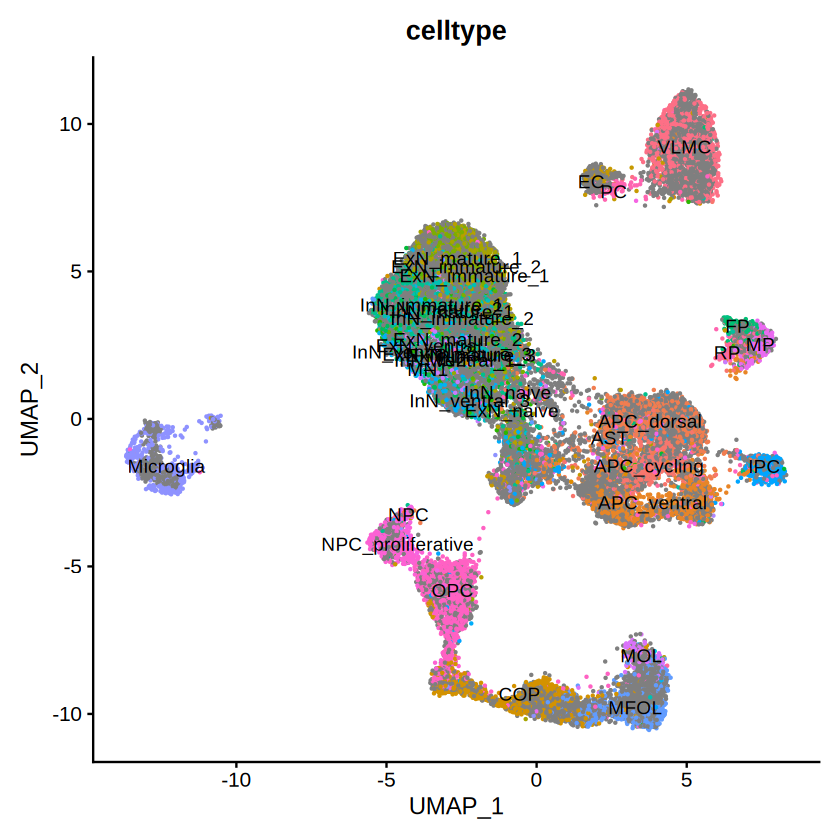

In [22]:
DimPlot(combined_sct, reduction = "umap", group.by = "celltype",  raster=FALSE, shuffle = TRUE, pt.size = 0.2,label = TRUE) + NoLegend()

# Mapping

In [23]:
k.neighbor = 10
dims = 1:20
combined_sct = Seurat::FindNeighbors(combined_sct, 
                                                k.param = k.neighbor,
                                                reduction="harmony",
                                                dims=dims, 
                                                return.neighbor = T, 
                                                assay = "integrated")
#---Find neighbors
combined_scRNA = suppressWarnings(subset(combined_sct, subset = dataset == "rna"))
combined_spatial = suppressWarnings(subset(combined_sct, subset = dataset == "spatial"))
cells_scrna = colnames(combined_scRNA)
cells_spatial = colnames(combined_spatial)
neigbors = suppressWarnings(sapply(cells_spatial, function(i){
    Seurat::TopNeighbors(combined_sct@neighbors$integrated.nn, i, n = k.neighbor)
}))
neigbors = as.data.frame(neigbors)
neigbors = as.list(neigbors)
#---Keep only neighbors found in the scRNA dataset
neigbors_scRNA = lapply(neigbors, function(x){
    x = x[x %in% cells_scrna]
})

# Check the minimum and maximum number of entries in `neigbors_scRNA`
min(sapply(neigbors_scRNA, length)) #0
max(sapply(neigbors_scRNA, length)) #49
# Count how many entries fall into specific ranges
sum(sapply(neigbors_scRNA, length) == 0) #2762
sum(sapply(neigbors_scRNA, length) == 1) #2095
sum(sapply(neigbors_scRNA, length) == 2) #1553
sum(sapply(neigbors_scRNA, length) > 10) #2549
sum(sapply(neigbors_scRNA, length) < 10) #10270

Computing nearest neighbors



Only one graph name supplied, storing nearest-neighbor graph only

ATAC assay doesn't leave any cells, so it is removed



[1] 0

[1] 9

[1] 5664

[1] 4118

[1] 2766

[1] 0

[1] 17032

In [24]:
# Integration ratio
1 - sum(sapply(neigbors_scRNA, length) == 0) / length(neigbors_scRNA) #1

[1] 0.6674495

In [25]:
# keep neighbors = k
neigbors_k = list()
k = 10
x = cells_spatial[1]
# Iterate over the barcode of each spatial cell
for (x in cells_spatial) { 
    # Retrieve the neighbors of each spatial cell, restricted to RNA neighbors only; some entries may therefore be empty
    neigbor = neigbors_scRNA[[x]]   
    # If the number of RNA neighbors is at least k, keep the first k RNA neighbors for this spatial cell
    if(length(neigbor) >= k){ 
        neigbors_k[[x]] = neigbor[1:k]
    }
    # If the number of RNA neighbors is less than k, borrow RNA neighbors from the spatial neighbors of this spatial cell
    if(length(neigbor) < k){
        # `neigbor_sp` contains all neighbors of the spatial cell, including RNA and spatial neighbors
        neigbor_sp = neigbors[[x]]
        # Restrict `neigbor_sp` to spatial neighbors only
        neigbor_sp = neigbor_sp[neigbor_sp %in% cells_spatial]
        neigbor = sapply(neigbor_sp,function(m){
            m = neigbors_scRNA[[m]]
        })
        # Collect unique RNA neighbors from the cell itself and its neighboring spatial cells
        neigbor = unique(unlist(neigbor))
        # Then take the first ten of these neighbors as the RNA neighbors of x; if none are available, NA will be returned
        neigbors_k[[x]] = neigbor[1:k]
    }
}
# `neigbors_k` is a list in which each element stores the RNA neighbors of one spatial cell. Some dense spatial cells may still fail to obtain RNA neighbors even after borrowing information from nearby spots.


# Count entries composed entirely of "NA"
na_values <- length(names(neigbors_k[sapply(neigbors_k, function(x) all(x == "NA"))])) #20
na_values
# This indicates that 20 spatial cells could not be assigned any RNA neighbors during neighbor search

[1] 1079

In [26]:
#----Map annotations based on neighbors
map = data.frame(cells = names(neigbors_k), celltype = NA, row.names = names(neigbors_k))
i = rownames(map)[1]
getmode <- function(v) {
    uniqv <- unique(v)
    uniqv[which.max(tabulate(match(v, uniqv)))]
}
for (i in rownames(map)) {
    cells = neigbors_k[[i]]
    indx1 = which(colnames(combined_scRNA) %in% cells)
    if (length(indx1) > 1) {
        map[i,"celltype"] = getmode(combined_scRNA$celltype[indx1])
    }
}
# These are the mapped annotations for spatial cells. Ideally, all RNA cell types should be represented, but losing very rare cell types is acceptable when the reference contains too few cells for a given developmental stage.
table(map$celltype)


      APC_cycling        APC_dorsal       APC_ventral               COP 
              502              1284              1243              1063 
               EC    ExN_immature_1    ExN_immature_2    ExN_immature_3 
              119               808              1047                33 
     ExN_mature_1      ExN_mature_2      ExN_mature_3         ExN_naive 
              905                80               135               112 
      ExN_ventral                FP    InN_immature_1    InN_immature_2 
              437                24               996                72 
     InN_mature_1      InN_mature_2         InN_naive     InN_ventral_1 
              892               129               222               226 
    InN_ventral_2     InN_ventral_3               IPC              MFOL 
              229               236               323              1026 
        Microglia               MN1               MN2               MOL 
              256                23               

In [27]:
combined_sct$celltype[rownames(map)] = map$celltype
table(combined_sct$celltype)


      APC_cycling        APC_dorsal       APC_ventral               AST 
             1186              2499              2469                53 
              COP                EC    ExN_immature_1    ExN_immature_2 
             1939               338              1282              1610 
   ExN_immature_3      ExN_mature_1      ExN_mature_2      ExN_mature_3 
               96              1547               265               301 
        ExN_naive       ExN_ventral                FP    InN_immature_1 
              247               848               193              1574 
   InN_immature_2      InN_mature_1      InN_mature_2         InN_naive 
              272              1443               312               256 
    InN_ventral_1     InN_ventral_2     InN_ventral_3               IPC 
              354               490               416               893 
             MFOL         Microglia               MN1               MN2 
             1575               771               

In [28]:
palette3 <- distinctColorPalette(length(unique(combined_sct$celltype)))
pt.size = 0.2
pdf("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/plot/p3_Dimplot_integrated.pdf", height = 6, width = 14)
DimPlot(combined_sct, reduction = "umap", group.by = "integrated_snn_res.0.8", cols = palette3, pt.size = pt.size)+
    (DimPlot(combined_sct, reduction = "umap", group.by = "celltype", cols = palette2, raster=FALSE, shuffle = TRUE, pt.size = pt.size,label = TRUE) + NoLegend())
dev.off()

pdf 
  2

In [29]:
combined_scRNA = suppressWarnings(subset(combined_sct, subset = dataset == "rna"))
combined_spatial = suppressWarnings(subset(combined_sct, subset = dataset == "spatial"))

ATAC assay doesn't leave any cells, so it is removed



In [30]:
cod = combined_spatial@meta.data[,c("x","y")]
colnames(cod) = c("cod1","cod2")
drsub =CreateDimReducObject(
    assay = "RNA",
    embeddings = as.matrix(cod),
    key = "cod_"
)
combined_spatial@reductions[["cod"]] = drsub
meta_sp <- combined_spatial@meta.data
head(meta_sp)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,cell,x,y,RNA_snn_res.0.5,seurat_clusters,⋯,TSS.percentile,UMAP_1,UMAP_2,barcode2,cell_type_snRNA,major_type,celltype,nCount_SCT,nFeature_SCT,integrated_snn_res.0.8
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<fct>
GW16:16530_9420,GW16,602,308,602,308,GW16:16530_9420,16530,9420,0,0,⋯,NA,NA,NA,NA,NA,NA,ExN_mature_1,601,307,0
GW16:13710_8340,GW16,748,381,748,381,GW16:13710_8340,13710,8340,0,6,⋯,NA,NA,NA,NA,NA,NA,OPC,664,381,6
GW16:12900_9690,GW16,1147,555,1147,555,GW16:12900_9690,12900,9690,1,7,⋯,NA,NA,NA,NA,NA,NA,MFOL,783,553,7
GW16:14640_9600,GW16,1397,695,1397,695,GW16:14640_9600,14640,9600,8,13,⋯,NA,NA,NA,NA,NA,NA,MP,497,326,13
GW16:15150_9660,GW16,1437,737,1437,737,GW16:15150_9660,15150,9660,0,0,⋯,NA,NA,NA,NA,NA,NA,ExN_mature_1,492,355,0
GW16:14490_8430,GW16,879,438,879,438,GW16:14490_8430,14490,8430,0,0,⋯,NA,NA,NA,NA,NA,NA,ExN_mature_1,667,437,0


cols <- c("#b5e48c", #Astrocytes
          # "#76c893", #APC
          "#34a0a4", #mGPC
          "#168aad", #OPC
          # "#1a759f", #COP
          # "#1e6091", #MFOL
          # "#184e77", #MOL
          "#faa275", #NPC
          "#e26d5c", #Ex-IN
          "#ce6a85", #In-IN
          "#c34e61", #MN
          "#8367c7", #DRG
          "#d9ed92", #Ependymal          
          "#ba6eac", #Schwann
          "#eca9b8", #EC
          "#cb909d", #Pericytes
          "#ddb786", #VLMC
          "#ecb222"  #Microglia
)
combined_spatial$cell_type <- factor((combined_spatial$cell_type), levels = c("Astrocytes", "mGPC", "OPC", "NPC", "Ex-IN", 
                                                  "In-IN", "MN", "DRG", "Ependymal", "Schwann", "EC",
                                                  "Pericytes", "VLMC", "Microglia"
))


In [31]:
palette2 <- distinctColorPalette(length(unique(combined_spatial$celltype)))
pdf("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/plot/p4_Codplot_annote_raw.pdf", height = 10, width = 11)
DimPlot(combined_spatial, reduction = "cod", group.by = "celltype", cols = palette2, pt.size = 1.5)
dev.off()

pdf 
  2

In [34]:
library(ggplot2)

# Count the number of cell types to determine the layout and canvas size automatically
cell_types <- sort(unique(combined_spatial$celltype))
n_types <- length(cell_types)

# Define the layout: for example, place 5 panels per row
n_col <- 5
n_row <- ceiling(n_types / n_col)

# Dynamically compute the PDF size (about 4x4 inches per panel is appropriate)
pdf_width <- n_col * 4
pdf_height <- n_row * 4

# Plot
p <- DimPlot(
  combined_spatial, 
  reduction = "cod", 
  group.by = "celltype", 
  split.by = "celltype",   # Key setting for faceted plotting
  ncol = n_col,            # Number of panels per row
  cols = palette2, 
  pt.size = 1.2
) + 
  coord_fixed() +          # Preserve spatial aspect ratio
  theme_bw() +             # Use a clean background
  NoLegend()               # Turn off the side legend to save space because panel titles already indicate the cell type

# Save
pdf("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/plot/p5_Codplot_split_clean.pdf", 
    height = pdf_height, width = pdf_width)
print(p)
dev.off()

pdf 
  2

In [32]:
meta_sp = combined_spatial@meta.data
#meta_sp = meta_sp[c(1:10,15,19:22)]
obj@meta.data = meta_sp

In [33]:
table(obj$celltype)


      APC_cycling        APC_dorsal       APC_ventral               COP 
              502              1284              1243              1063 
               EC    ExN_immature_1    ExN_immature_2    ExN_immature_3 
              119               808              1047                33 
     ExN_mature_1      ExN_mature_2      ExN_mature_3         ExN_naive 
              905                80               135               112 
      ExN_ventral                FP    InN_immature_1    InN_immature_2 
              437                24               996                72 
     InN_mature_1      InN_mature_2         InN_naive     InN_ventral_1 
              892               129               222               226 
    InN_ventral_2     InN_ventral_3               IPC              MFOL 
              229               236               323              1026 
        Microglia               MN1               MN2               MOL 
              256                23               

In [35]:
sum(is.na(obj$celltype))

[1] 2112

In [36]:
keep_cells <- which(!is.na(obj@meta.data$celltype))
# Retain these cells
obj <- obj[, keep_cells]
obj

An object of class Seurat 
26991 features across 14920 samples within 1 assay 
Active assay: RNA (26991 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: cod, pca, umap, tsne

In [37]:
saveRDS(obj, file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/1.GW16_obj_annote_bin30.rds")

In [38]:
anno = obj@meta.data[,c("cell","celltype")]
write.csv(anno, "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/spatial_anno.csv")